In [2]:
# Import Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA_DE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

df_DA_DE = df_DA_DE.dropna(subset=['salary_year_avg'])

df_DA_DE['salary_year_avg'].sample(10)

411664     89100.0
714049    200000.0
89707      80850.0
661253    102500.0
210187     77017.5
412713     51014.0
127888    111175.0
754794    111202.0
580643    111175.0
137735    105650.0
Name: salary_year_avg, dtype: float64

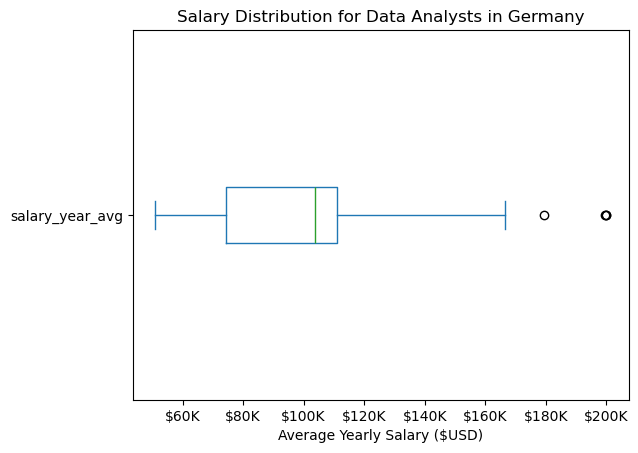

In [7]:
df_DA_DE['salary_year_avg'].plot(kind='box', vert=False)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.title('Salary Distribution for Data Analysts in Germany')
plt.xlabel('Average Yearly Salary ($USD)')
plt.show()

# For The Major Job Roles

In [12]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_DE = df[(df['job_title_short'].isin(job_titles) & (df['job_country'] == 'Germany'))].copy()
df_DE = df_DE.dropna(subset=['salary_year_avg'])

job_list = [df_DE[df_DE['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

/var/folders/x4/q8t78mvx6xs5b2jwtybtn5rw0000gn/T/ipykernel_88490/1739449348.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, vert=False, labels=job_titles)


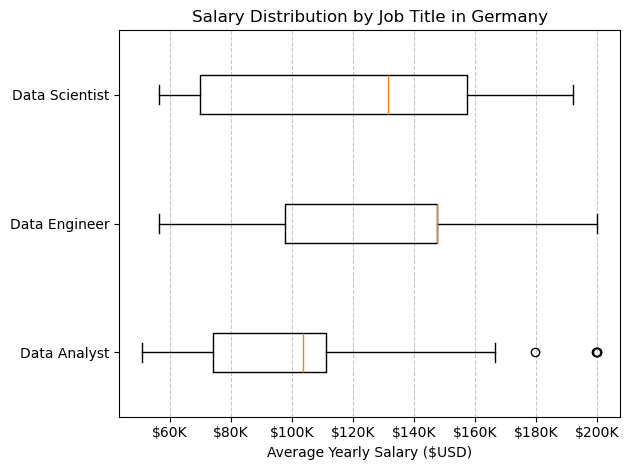

In [20]:
plt.boxplot(job_list, vert=False, labels=job_titles)
plt.title('Salary Distribution by Job Title in Germany')
plt.xlabel('Average Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()